# 📊 Read the Signs: Tomorrow's Mood, Today's Data
## DSA 210 – Spring 2026 | Milestone 1: EDA & Hypothesis Testing
### Yigit Manafi

---

**Objective:** Can we predict how we will feel tomorrow by looking at today's data?

This notebook covers **Exploratory Data Analysis (EDA)** and **Hypothesis Testing** on 398 days of personal self-tracked data including mood, sleep, heart rate, stress, physical activity, and exam schedules.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, mannwhitneyu, shapiro, kruskal
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df = pd.read_excel('data/master_data_v2_filled.xlsx')
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Total days tracked: {df.shape[0]}")
print(f"\nColumns ({len(df.columns)}): {list(df.columns)}")
df.head(10)

Dataset shape: (398, 11)
Date range: 2025-03-06 to 2026-04-07
Total days tracked: 398

Columns (11): ['date', 'day_name', 'is_weekend', 'mood', 'sleep_duration_h', 'deep_sleep_min', 'rem_sleep_min', 'bedtime', 'avg_heart_rate', 'resting_heart_rate', 'days_until_exam']


,date,day_name,is_weekend,mood,sleep_duration_h,deep_sleep_min,rem_sleep_min,bedtime,avg_heart_rate,resting_heart_rate,days_until_exam
0,2025-03-06,Thursday,0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,247
1,2025-03-07,Friday,0,2.0,NaN,NaN,NaN,NaN,69.0,NaN,246
2,2025-03-08,Saturday,1,NaN,11.40,232.0,77.0,18:58,62.0,NaN,245
3,2025-03-09,Sunday,1,NaN,8.68,135.0,103.0,22:27,67.0,NaN,244
4,2025-03-10,Monday,0,NaN,6.50,101.0,75.0,23:00,80.0,56.0,243
5,2025-03-11,Tuesday,0,NaN,2.05,0.0,NaN,23:04,77.0,66.0,242
6,2025-03-12,Wednesday,0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,241
7,2025-03-13,Thursday,0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,240
8,2025-03-14,Friday,0,4.0,NaN,NaN,NaN,NaN,88.0,62.0,239
9,2025-03-15,Saturday,1,3.0,6.38,114.0,72.0,21:03,79.0,56.0,238


## 3. Data Cleaning & Feature Engineering

### 3.1 Mood Scale
Mood is self-reported daily on a 1–5 scale in 0.5 increments (1.0, 1.5, 2.0, ..., 5.0).

In [3]:
print("Mood scale values:", sorted(df['mood'].dropna().unique()))
print(f"\nDays with mood data: {df['mood'].notna().sum()} / {len(df)}")
print(f"Days without mood: {df['mood'].isna().sum()}")
print(f"\nMood distribution:")
print(df['mood'].value_counts().sort_index())

Mood scale values: [np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]

Days with mood data: 305 / 398
Days without mood: 93

Mood distribution:
mood
1.0     15
1.5      7
2.0     33
2.5     48
3.0    120
3.5     30
4.0     42
4.5      6
5.0      4
Name: count, dtype: int64


### 3.2 Feature Engineering

- **Next-day mood target:** `mood_tomorrow` — today's row holds tomorrow's mood via a one-day shift.
- **Sleep quality composite:** Z-score average of sleep duration, deep sleep, and REM sleep.
- **Exam proximity categories:** Days until exam grouped into actionable bins.

In [4]:
# Next-day mood target
df['mood_tomorrow'] = df['mood'].shift(-1)

# Bedtime to numeric hours (relative to midnight)
def time_to_hours(t):
    if pd.isna(t):
        return np.nan
    try:
        parts = str(t).split(':')
        h, m = int(parts[0]), int(parts[1])
        return (h + m/60 - 24) if h >= 18 else (h + m/60)
    except:
        return np.nan

df['bedtime_numeric'] = df['bedtime'].apply(time_to_hours)

# Sleep quality composite (z-score)
for col in ['sleep_duration_h', 'deep_sleep_min', 'rem_sleep_min']:
    df[f'{col}_z'] = (df[col] - df[col].mean()) / df[col].std()
df['sleep_quality'] = df[['sleep_duration_h_z', 'deep_sleep_min_z', 'rem_sleep_min_z']].mean(axis=1)

# Exam proximity categories
def exam_proximity(days):
    if pd.isna(days): return 'Unknown'
    if days <= 3: return 'Exam <= 3 days'
    elif days <= 7: return 'Exam 4-7 days'
    elif days <= 14: return 'Exam 1-2 weeks'
    else: return 'No upcoming exam'

df['exam_category'] = df['days_until_exam'].apply(exam_proximity)

# Tomorrow is weekend flag
df['tomorrow_is_weekend'] = df['is_weekend'].shift(-1)

# Tomorrow is weekend flag
df['tomorrow_is_weekend'] = df['is_weekend'].shift(-1)

print("Feature engineering complete.")
print(f"Rows with both today's & tomorrow's mood: {df[['mood', 'mood_tomorrow']].dropna().shape[0]}")

Feature engineering complete.
Rows with both today's & tomorrow's mood: 285


### 3.3 Descriptive Statistics & Missing Data

In [5]:
key_cols = ['mood', 'sleep_duration_h', 'deep_sleep_min', 'rem_sleep_min',
            'avg_heart_rate', 'resting_heart_rate', 'days_until_exam']

print("=== Descriptive Statistics ===\n")
print(df[key_cols].describe().round(2).to_string())

=== Descriptive Statistics ===

         mood  sleep_duration_h  deep_sleep_min  rem_sleep_min  avg_heart_rate  resting_heart_rate  days_until_exam
count  305.00            305.00          305.00         288.00          335.00              327.00           398.00
mean     2.92              6.89          119.06          68.17           75.83               62.65            84.06
std      0.81              2.16           57.82          28.35            6.81                6.94            76.99
min      1.00              0.42            0.00          15.00           58.00               51.00             0.00
25%      2.50              5.68           89.00          48.00           70.50               58.00            13.00
50%      3.00              7.03          119.00          63.00           76.00               62.00            58.50
75%      3.50              8.43          154.00          82.00           81.00               66.00           147.75
max      5.00             12.62         

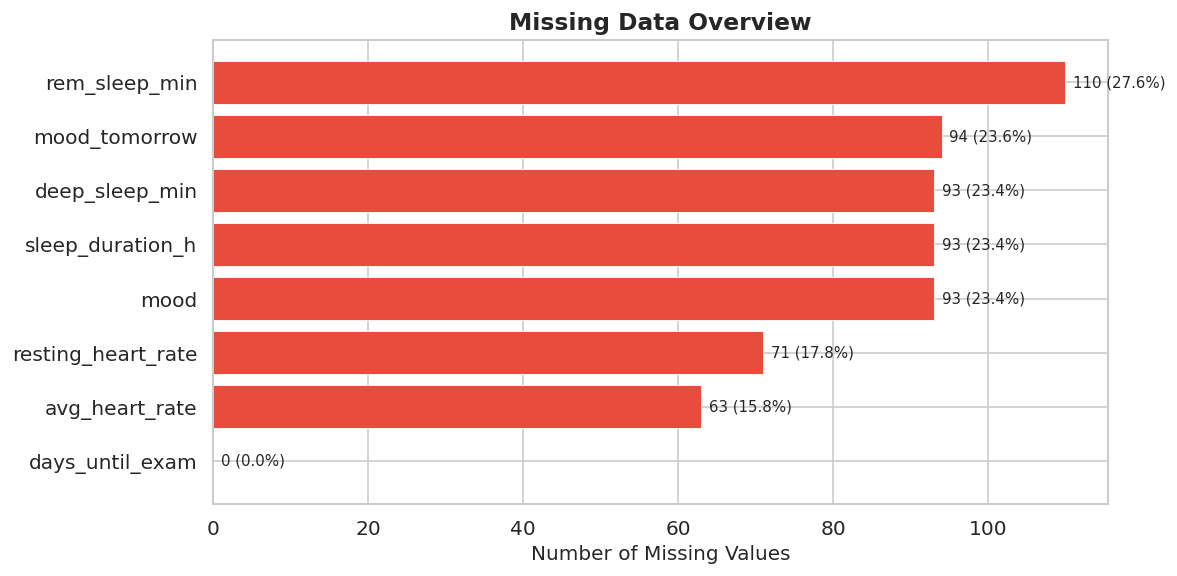

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

missing = df[key_cols + ['mood_tomorrow']].isnull().sum().sort_values(ascending=True)
colors = ['#e74c3c' if v > 30 else '#f39c12' if v > 10 else '#2ecc71' for v in missing.values]

bars = ax.barh(missing.index, missing.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Number of Missing Values')
ax.set_title('Missing Data Overview', fontweight='bold')

for bar, val in zip(bars, missing.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/01_missing_data.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Exploratory Data Analysis (EDA)

### 4.1 Mood Distribution

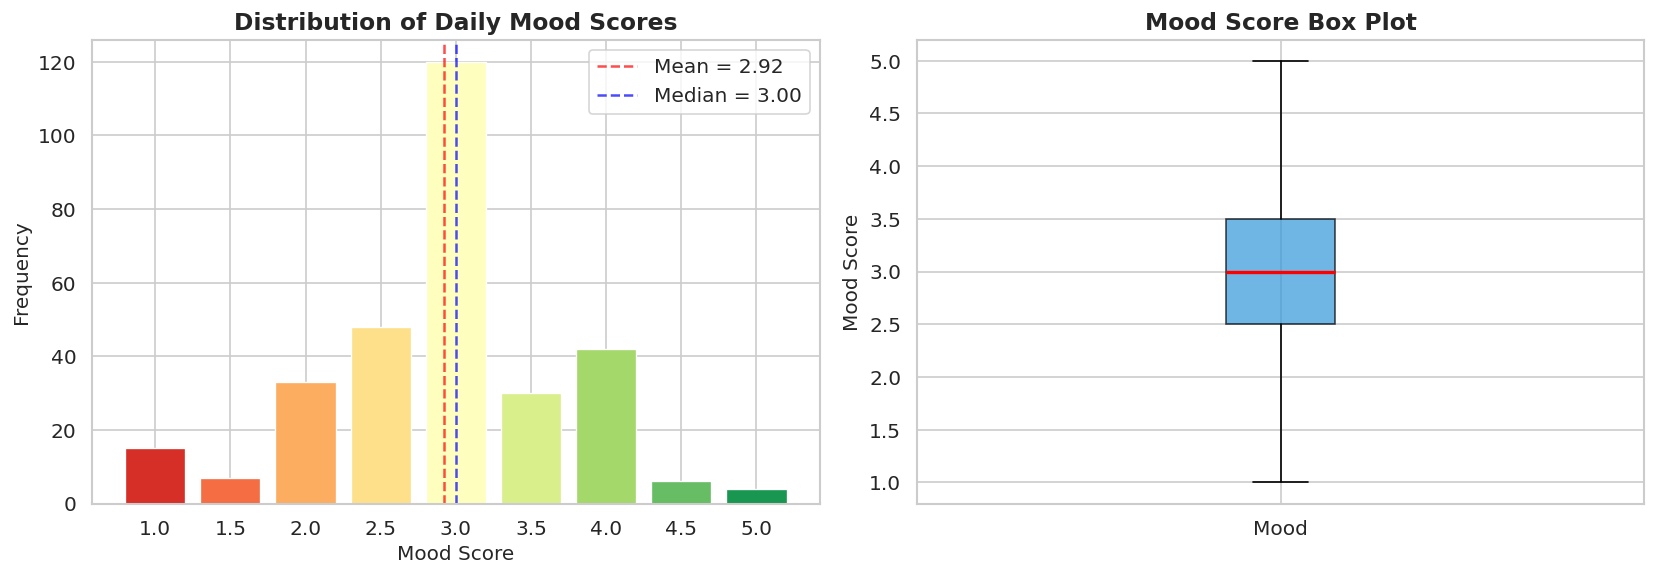

Mean: 2.92  |  Median: 3.00  |  Std: 0.81  |  Skew: -0.24


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mood_data = df['mood'].dropna()
counts = mood_data.value_counts().sort_index()
colors_mood = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(counts)))

axes[0].bar(counts.index, counts.values, width=0.4, color=colors_mood, edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Mood Score'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Daily Mood Scores', fontweight='bold')
axes[0].set_xticks(np.arange(1, 5.5, 0.5))
axes[0].axvline(mood_data.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean = {mood_data.mean():.2f}')
axes[0].axvline(mood_data.median(), color='blue', linestyle='--', alpha=0.7, label=f'Median = {mood_data.median():.2f}')
axes[0].legend()

bp = axes[1].boxplot(mood_data, vert=True, patch_artist=True,
                      boxprops=dict(facecolor='#3498db', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Mood Score'); axes[1].set_title('Mood Score Box Plot', fontweight='bold')
axes[1].set_xticklabels(['Mood'])

plt.tight_layout()
plt.savefig('figures/02_mood_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mean: {mood_data.mean():.2f}  |  Median: {mood_data.median():.2f}  |  Std: {mood_data.std():.2f}  |  Skew: {mood_data.skew():.2f}")

### 4.2 Mood Over Time

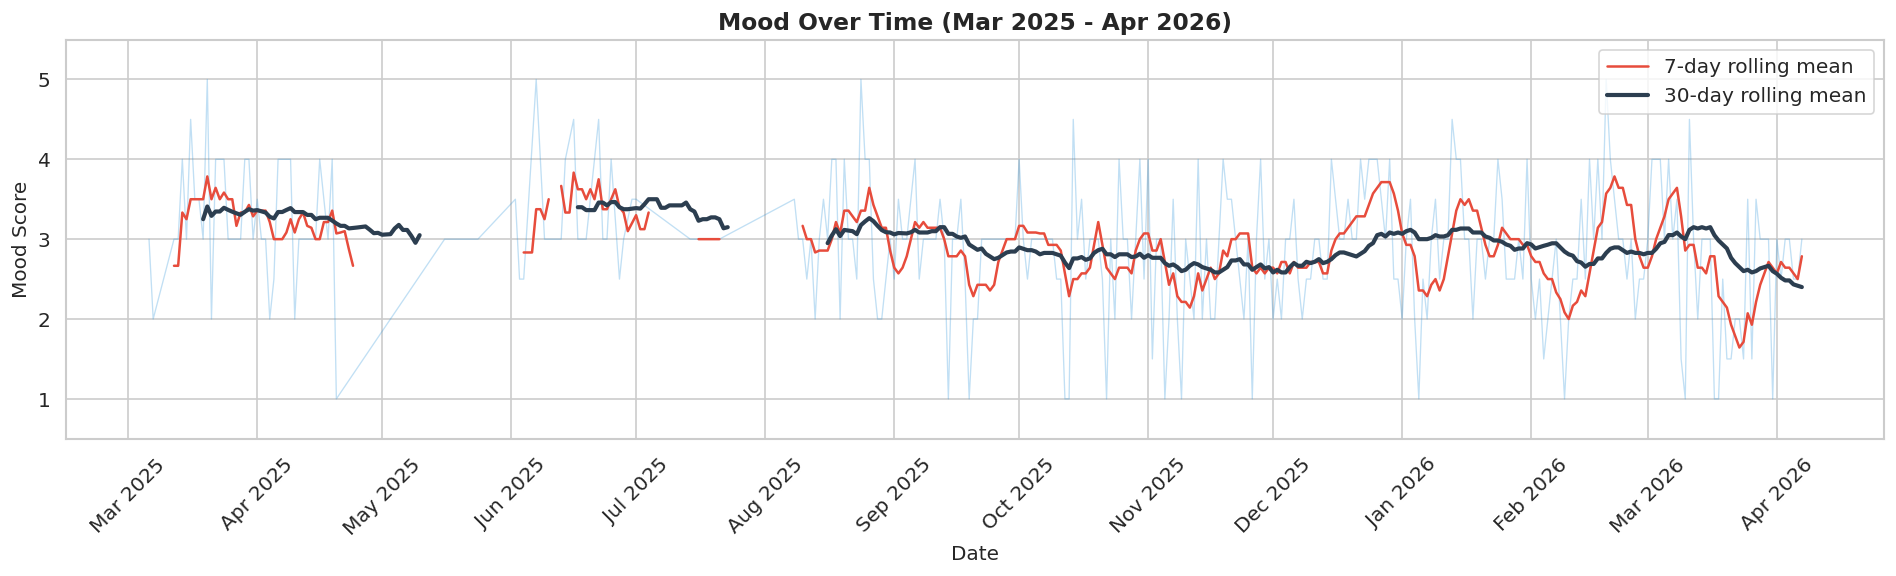

In [8]:
fig, ax = plt.subplots(figsize=(16, 5))

mood_ts = df[['date', 'mood']].dropna()
ax.plot(mood_ts['date'], mood_ts['mood'], alpha=0.3, color='#3498db', linewidth=0.8)

mood_idx = df.set_index('date')['mood']
ax.plot(mood_idx.rolling(7, min_periods=3).mean().index, mood_idx.rolling(7, min_periods=3).mean().values,
        color='#e74c3c', linewidth=1.5, label='7-day rolling mean')
ax.plot(mood_idx.rolling(30, min_periods=10).mean().index, mood_idx.rolling(30, min_periods=10).mean().values,
        color='#2c3e50', linewidth=2.5, label='30-day rolling mean')

ax.set_xlabel('Date'); ax.set_ylabel('Mood Score')
ax.set_title('Mood Over Time (Mar 2025 - Apr 2026)', fontweight='bold')
ax.legend(); ax.set_ylim(0.5, 5.5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/03_mood_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Mood by Day of Week & Weekend Effect

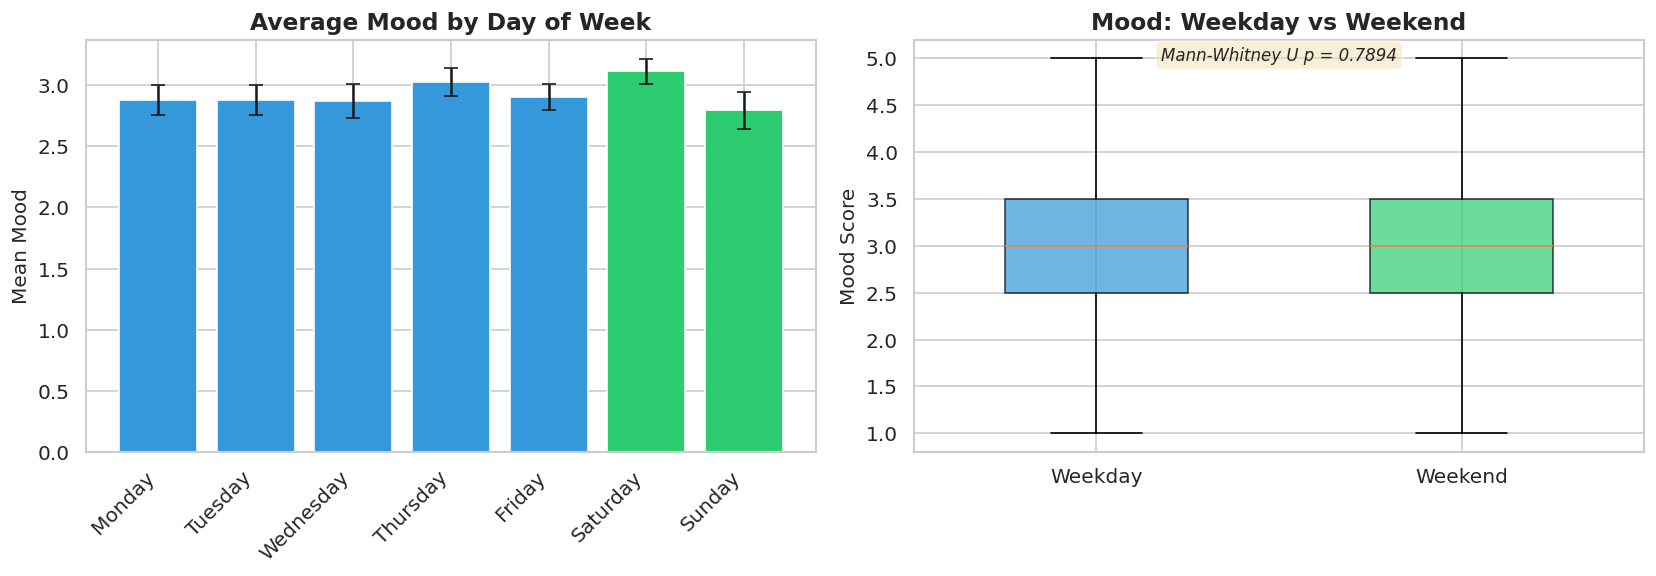

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_mood = df.groupby('day_name')['mood'].agg(['mean', 'std', 'count']).reindex(day_order)
colors_day = ['#2ecc71' if d in ['Saturday', 'Sunday'] else '#3498db' for d in day_order]

axes[0].bar(range(len(day_order)), day_mood['mean'],
            yerr=day_mood['std']/np.sqrt(day_mood['count']),
            color=colors_day, edgecolor='white', capsize=4)
axes[0].set_xticks(range(len(day_order)))
axes[0].set_xticklabels(day_order, rotation=45, ha='right')
axes[0].set_ylabel('Mean Mood'); axes[0].set_title('Average Mood by Day of Week', fontweight='bold')

weekend = df[df['is_weekend'] == 1]['mood'].dropna()
weekday = df[df['is_weekend'] == 0]['mood'].dropna()
bp = axes[1].boxplot([weekday, weekend], labels=['Weekday', 'Weekend'], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#3498db'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#2ecc71'); bp['boxes'][1].set_alpha(0.7)
axes[1].set_ylabel('Mood Score'); axes[1].set_title('Mood: Weekday vs Weekend', fontweight='bold')
stat, p = mannwhitneyu(weekday, weekend, alternative='two-sided')
axes[1].text(0.5, 0.95, f'Mann-Whitney U p = {p:.4f}', transform=axes[1].transAxes,
             ha='center', fontsize=10, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('figures/04_mood_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Correlation Heatmap

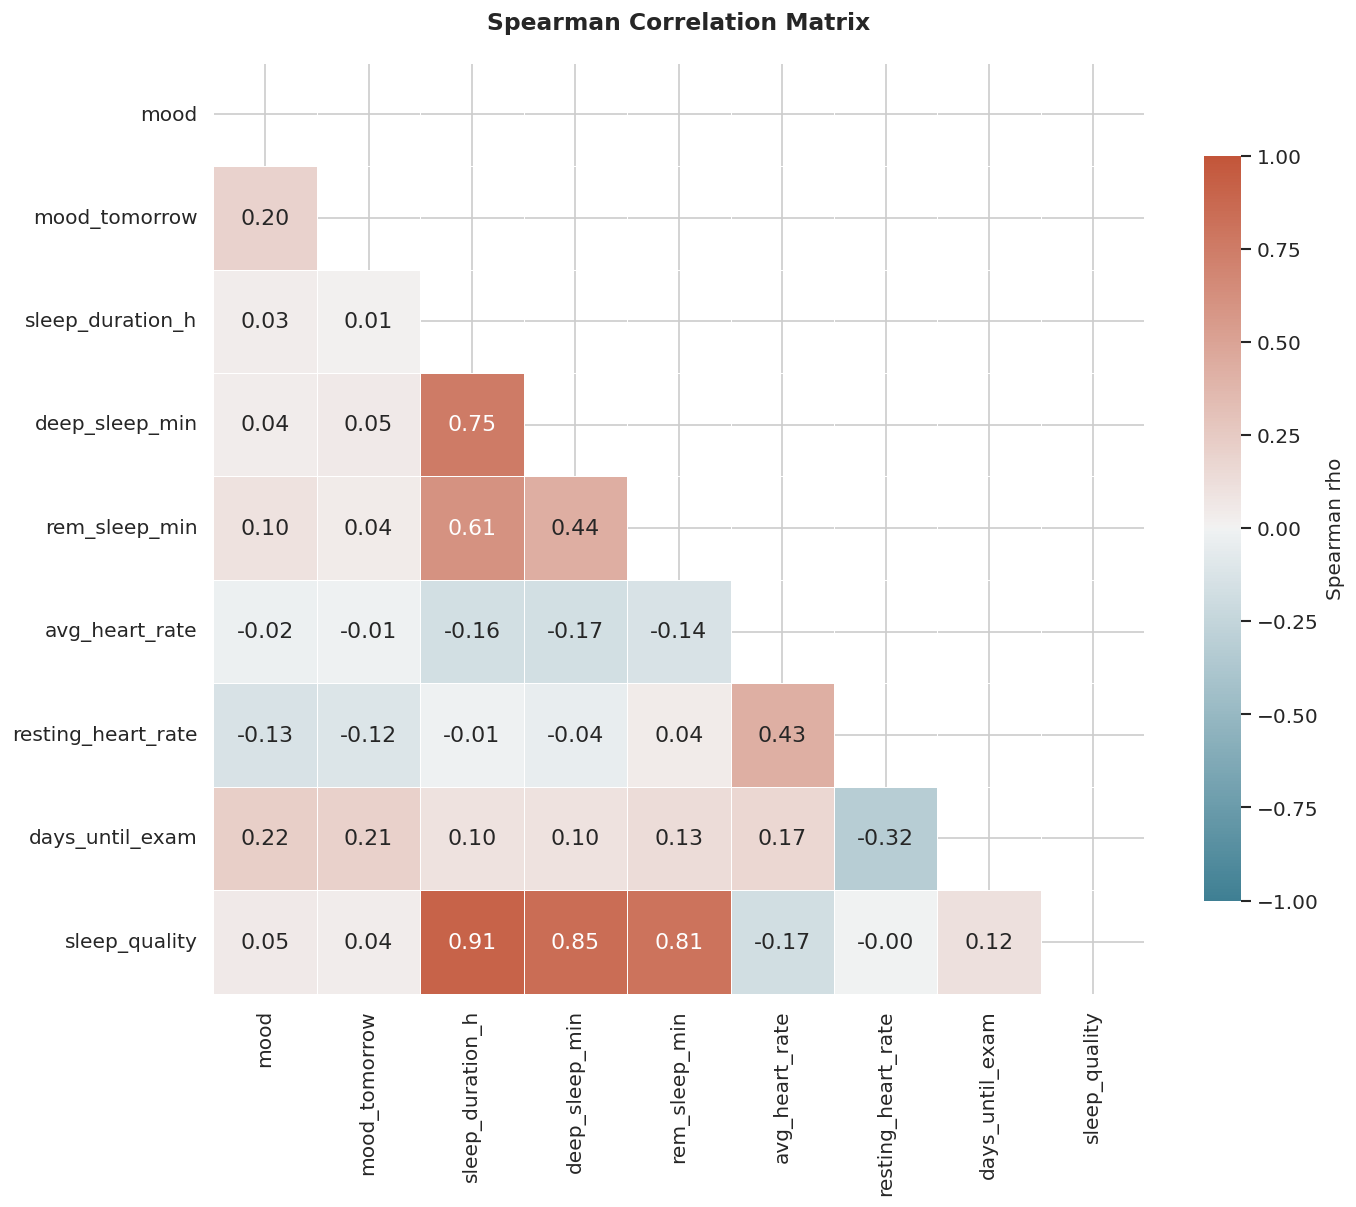

In [10]:
corr_cols = ['mood', 'mood_tomorrow', 'sleep_duration_h', 'deep_sleep_min', 'rem_sleep_min',
             'avg_heart_rate', 'resting_heart_rate', 'days_until_exam', 'sleep_quality']

fig, ax = plt.subplots(figsize=(12, 10))
corr = df[corr_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Spearman rho"}, vmin=-1, vmax=1)
ax.set_title('Spearman Correlation Matrix', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('figures/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Sleep Analysis

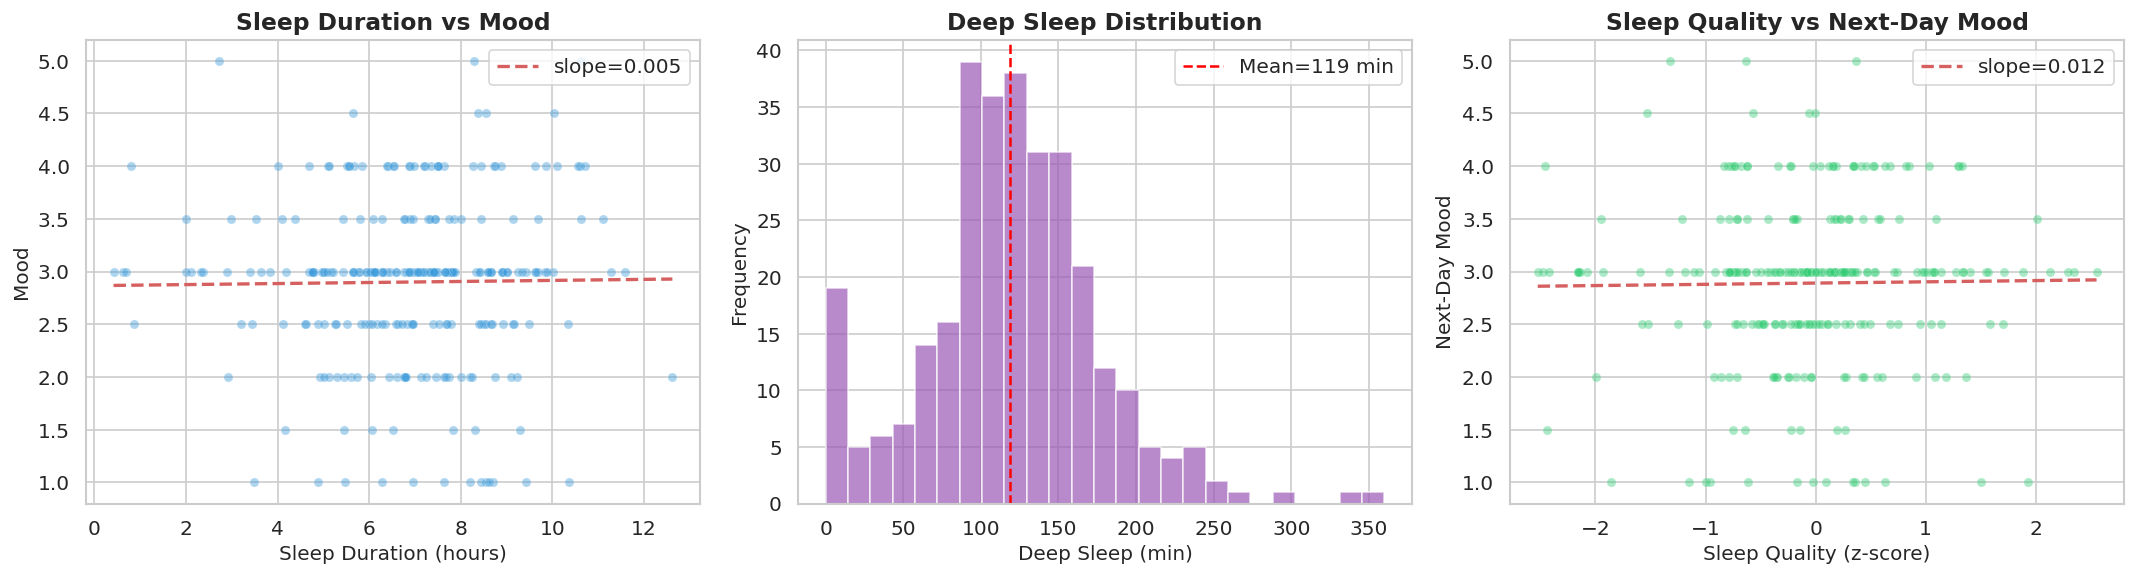

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sm = df[['sleep_duration_h', 'mood']].dropna()
axes[0].scatter(sm['sleep_duration_h'], sm['mood'], alpha=0.4, c='#3498db', s=30, edgecolors='white', linewidth=0.3)
z = np.polyfit(sm['sleep_duration_h'], sm['mood'], 1)
x_r = np.linspace(sm['sleep_duration_h'].min(), sm['sleep_duration_h'].max(), 100)
axes[0].plot(x_r, np.poly1d(z)(x_r), 'r--', linewidth=2, label=f'slope={z[0]:.3f}')
axes[0].set_xlabel('Sleep Duration (hours)'); axes[0].set_ylabel('Mood')
axes[0].set_title('Sleep Duration vs Mood', fontweight='bold'); axes[0].legend()

axes[1].hist(df['deep_sleep_min'].dropna(), bins=25, color='#9b59b6', alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Deep Sleep (min)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Deep Sleep Distribution', fontweight='bold')
axes[1].axvline(df['deep_sleep_min'].mean(), color='red', linestyle='--', label=f"Mean={df['deep_sleep_min'].mean():.0f} min")
axes[1].legend()

sq = df[['sleep_quality', 'mood_tomorrow']].dropna()
axes[2].scatter(sq['sleep_quality'], sq['mood_tomorrow'], alpha=0.4, c='#2ecc71', s=30, edgecolors='white', linewidth=0.3)
z2 = np.polyfit(sq['sleep_quality'], sq['mood_tomorrow'], 1)
x_r2 = np.linspace(sq['sleep_quality'].min(), sq['sleep_quality'].max(), 100)
axes[2].plot(x_r2, np.poly1d(z2)(x_r2), 'r--', linewidth=2, label=f'slope={z2[0]:.3f}')
axes[2].set_xlabel('Sleep Quality (z-score)'); axes[2].set_ylabel('Next-Day Mood')
axes[2].set_title('Sleep Quality vs Next-Day Mood', fontweight='bold'); axes[2].legend()

plt.tight_layout()
plt.savefig('figures/06_sleep_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Heart Rate & Physiological Indicators

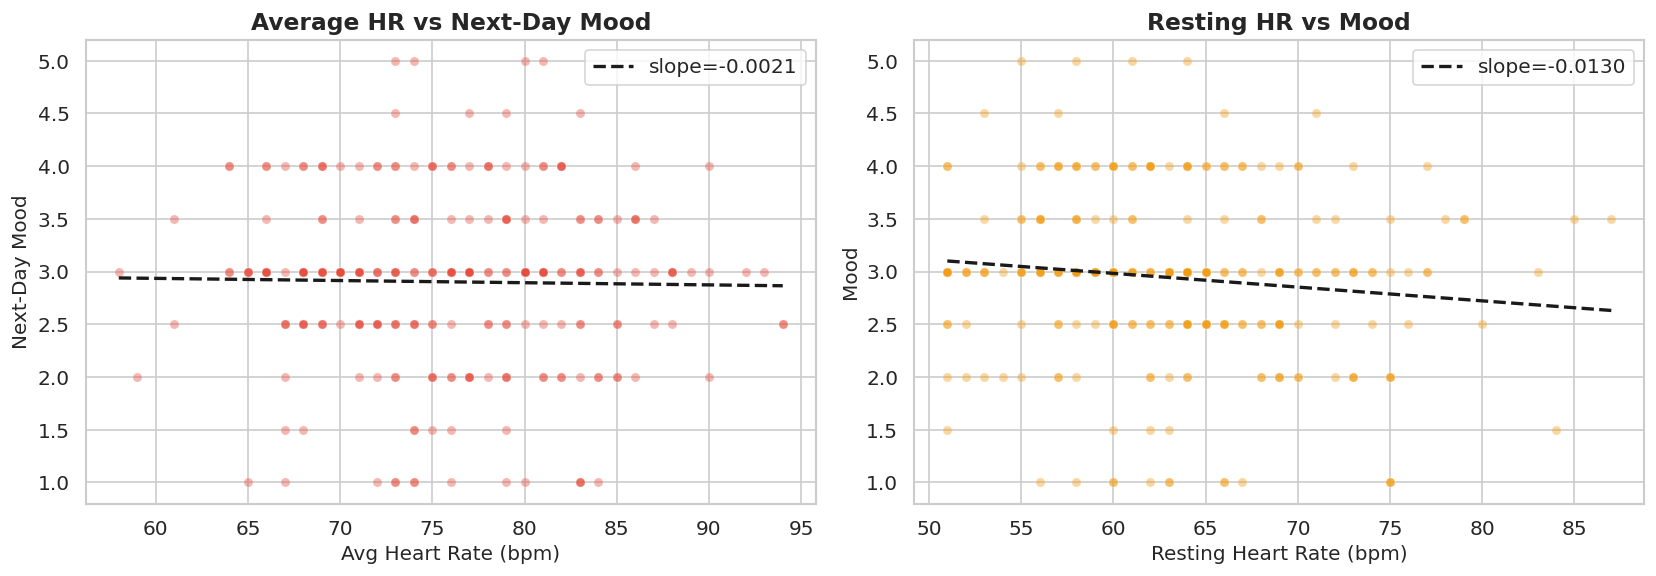

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hr = df[['avg_heart_rate', 'mood_tomorrow']].dropna()
axes[0].scatter(hr['avg_heart_rate'], hr['mood_tomorrow'], alpha=0.4, c='#e74c3c', s=30, edgecolors='white', linewidth=0.3)
z3 = np.polyfit(hr['avg_heart_rate'], hr['mood_tomorrow'], 1)
x_r3 = np.linspace(hr['avg_heart_rate'].min(), hr['avg_heart_rate'].max(), 100)
axes[0].plot(x_r3, np.poly1d(z3)(x_r3), 'k--', linewidth=2, label=f'slope={z3[0]:.4f}')
axes[0].set_xlabel('Avg Heart Rate (bpm)'); axes[0].set_ylabel('Next-Day Mood')
axes[0].set_title('Average HR vs Next-Day Mood', fontweight='bold'); axes[0].legend()

rhr = df[['resting_heart_rate', 'mood']].dropna()
axes[1].scatter(rhr['resting_heart_rate'], rhr['mood'], alpha=0.4, c='#f39c12', s=30, edgecolors='white', linewidth=0.3)
z4 = np.polyfit(rhr['resting_heart_rate'], rhr['mood'], 1)
x_r4 = np.linspace(rhr['resting_heart_rate'].min(), rhr['resting_heart_rate'].max(), 100)
axes[1].plot(x_r4, np.poly1d(z4)(x_r4), 'k--', linewidth=2, label=f'slope={z4[0]:.4f}')
axes[1].set_xlabel('Resting Heart Rate (bpm)'); axes[1].set_ylabel('Mood')
axes[1].set_title('Resting HR vs Mood', fontweight='bold'); axes[1].legend()

plt.tight_layout()
plt.savefig('figures/07_heart_rate.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.7 Exam Proximity & Mood

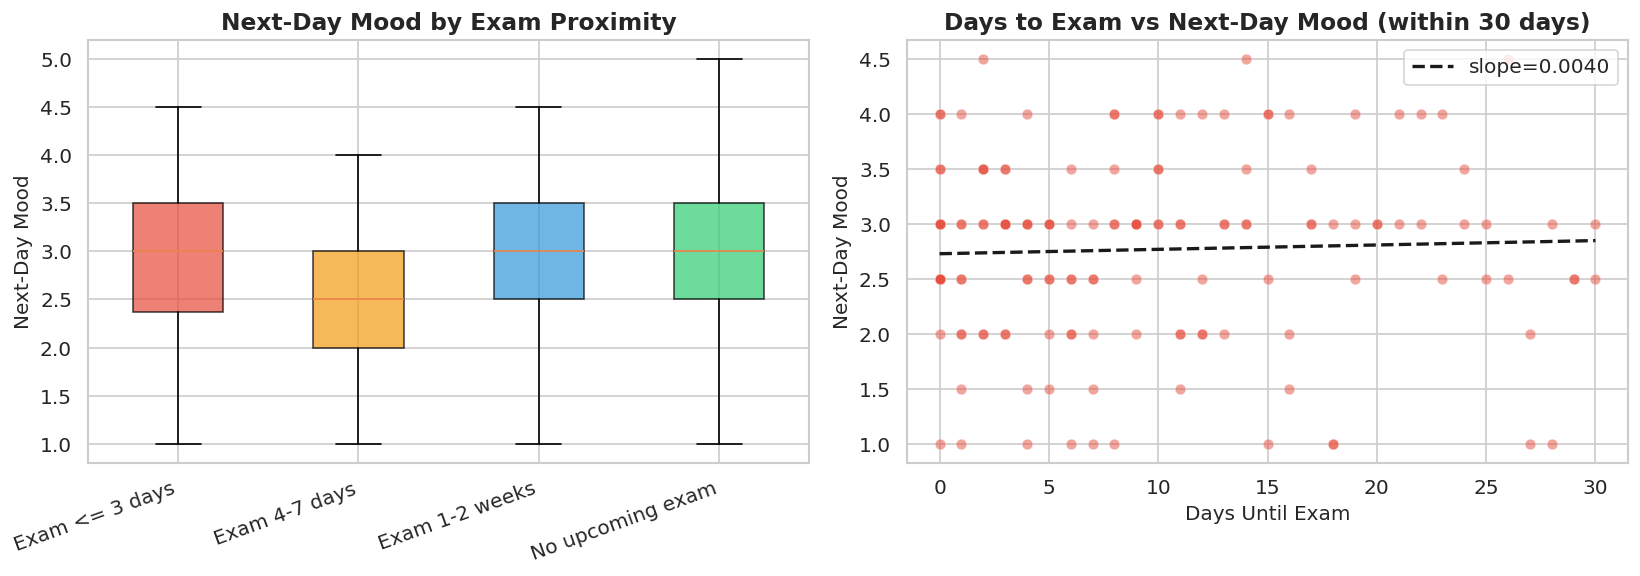

Exam <= 3 days           : mean=2.80, n=40
Exam 4-7 days            : mean=2.39, n=28
Exam 1-2 weeks           : mean=3.00, n=36
No upcoming exam         : mean=3.01, n=200


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_order = ['Exam <= 3 days', 'Exam 4-7 days', 'Exam 1-2 weeks', 'No upcoming exam']
cat_colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

exam_data = [df[df['exam_category'] == c]['mood_tomorrow'].dropna() for c in cat_order]
valid = [(d, c, col) for d, c, col in zip(exam_data, cat_order, cat_colors) if len(d) > 0]

bp = axes[0].boxplot([v[0] for v in valid], labels=[v[1] for v in valid], patch_artist=True, widths=0.5)
for patch, v in zip(bp['boxes'], valid):
    patch.set_facecolor(v[2]); patch.set_alpha(0.7)
axes[0].set_ylabel('Next-Day Mood')
axes[0].set_title('Next-Day Mood by Exam Proximity', fontweight='bold')
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')

ec = df[df['days_until_exam'] <= 30][['days_until_exam', 'mood_tomorrow']].dropna()
axes[1].scatter(ec['days_until_exam'], ec['mood_tomorrow'], alpha=0.5, c='#e74c3c', s=40, edgecolors='white', linewidth=0.3)
z5 = np.polyfit(ec['days_until_exam'], ec['mood_tomorrow'], 1)
axes[1].plot(np.linspace(0, 30, 100), np.poly1d(z5)(np.linspace(0, 30, 100)), 'k--', linewidth=2, label=f'slope={z5[0]:.4f}')
axes[1].set_xlabel('Days Until Exam'); axes[1].set_ylabel('Next-Day Mood')
axes[1].set_title('Days to Exam vs Next-Day Mood (within 30 days)', fontweight='bold'); axes[1].legend()

plt.tight_layout()
plt.savefig('figures/08_exam_mood.png', dpi=150, bbox_inches='tight')
plt.show()

for c in cat_order:
    d = df[df['exam_category'] == c]['mood_tomorrow'].dropna()
    if len(d) > 0: print(f"{c:25s}: mean={d.mean():.2f}, n={len(d)}")

---

## 5. Hypothesis Testing

**Significance level:** alpha = 0.05

| ID | Null (H0) | Alternative (H1) |
|---|---|---|
| H1a | Today's mood does **not** correlate with tomorrow's mood | Today's mood **positively** correlates with tomorrow's mood |
| H1b | Exam proximity has **no effect** on next-day mood | As exam day approaches, next-day mood **decreases** |
| H1c | Heart rate has **no association** with next-day mood | Higher heart rate is associated with **lower** next-day mood |
| H1d | Whether tomorrow is a weekend has **no effect** on next-day mood | Next-day mood is **higher** when tomorrow is a weekend |
| H1e | Sleep has **no effect** on next-day mood | Better sleep is associated with **higher** next-day mood |

**Primary test:** Spearman rank correlation (non-parametric, robust to non-normality)  
**Group comparisons:** Mann-Whitney U test, Kruskal-Wallis test

### 5.1 H1a: Mood Temporal Continuity
> **H0:** No correlation between today's mood and tomorrow's mood.  
> **H1:** Today's mood positively correlates with tomorrow's mood.

Sample size: n = 285

Shapiro-Wilk (mood): W = 0.9504, p = 0.0353
-> Not normal distribution. Using Spearman as primary test.

--- Spearman Correlation ---
rho = 0.1972, p = 0.000813
-> REJECT H0 at alpha = 0.05

--- Pearson (for comparison) ---
r = 0.1898, p = 0.001282


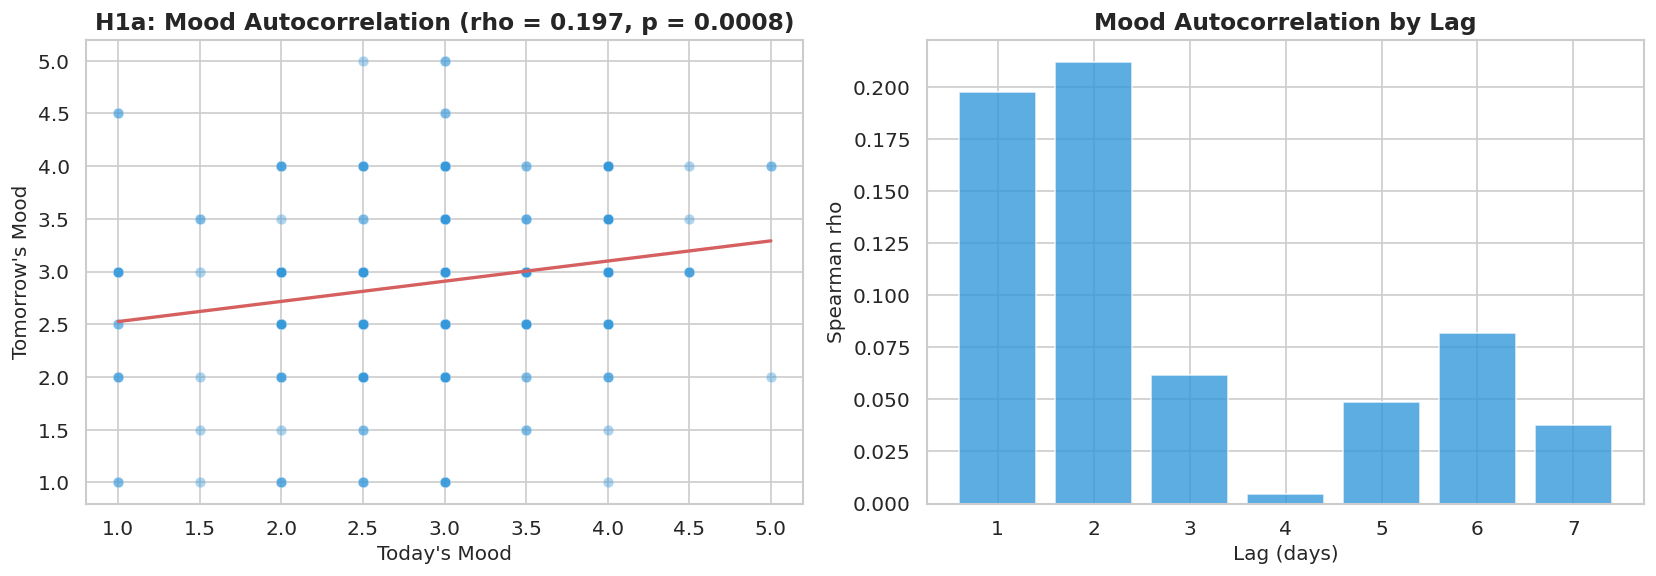

In [14]:
h1a = df[['mood', 'mood_tomorrow']].dropna()
print(f"Sample size: n = {len(h1a)}")

stat_n, p_n = shapiro(h1a['mood'].sample(min(50, len(h1a)), random_state=42))
print(f"\nShapiro-Wilk (mood): W = {stat_n:.4f}, p = {p_n:.4f}")
print(f"-> {'Normal' if p_n > 0.05 else 'Not normal'} distribution. Using Spearman as primary test.")

rho_s, p_s = spearmanr(h1a['mood'], h1a['mood_tomorrow'])
print(f"\n--- Spearman Correlation ---")
print(f"rho = {rho_s:.4f}, p = {p_s:.6f}")
print(f"-> {'REJECT H0' if p_s < 0.05 else 'FAIL TO REJECT H0'} at alpha = 0.05")

rho_p, p_p = pearsonr(h1a['mood'], h1a['mood_tomorrow'])
print(f"\n--- Pearson (for comparison) ---")
print(f"r = {rho_p:.4f}, p = {p_p:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(h1a['mood'], h1a['mood_tomorrow'], alpha=0.4, c='#3498db', s=40, edgecolors='white', linewidth=0.3)
z = np.polyfit(h1a['mood'], h1a['mood_tomorrow'], 1)
x_r = np.linspace(h1a['mood'].min(), h1a['mood'].max(), 100)
axes[0].plot(x_r, np.poly1d(z)(x_r), 'r-', linewidth=2)
axes[0].set_xlabel("Today's Mood"); axes[0].set_ylabel("Tomorrow's Mood")
axes[0].set_title(f"H1a: Mood Autocorrelation (rho = {rho_s:.3f}, p = {p_s:.4f})", fontweight='bold')

lags = range(1, 8)
lag_corrs = []
for lag in lags:
    valid = pd.DataFrame({'o': df['mood'], 'l': df['mood'].shift(lag)}).dropna()
    r, _ = spearmanr(valid['o'], valid['l']) if len(valid) > 10 else (np.nan, np.nan)
    lag_corrs.append(r)

axes[1].bar(lags, lag_corrs, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Lag (days)'); axes[1].set_ylabel('Spearman rho')
axes[1].set_title('Mood Autocorrelation by Lag', fontweight='bold')
axes[1].axhline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig('figures/11_h1a_mood_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 H1b: Exam Proximity & Next-Day Mood
> **H0:** Exam proximity has no effect on next-day mood.  
> **H1:** As exam day approaches, next-day mood decreases.

Sample size (within 30 days of exam): n = 142

--- Spearman (days to exam vs next-day mood) ---
rho = 0.0584, p = 0.490132
-> FAIL TO REJECT H0 at alpha = 0.05

--- Mann-Whitney U: Exam <= 3 days vs No upcoming exam ---
U = 3443, p = 0.074440
Close: mean = 2.80 (n=40)  |  Far: mean = 3.01 (n=200)
-> FAIL TO REJECT H0 at alpha = 0.05

--- Kruskal-Wallis (all categories) ---
H = 15.8551, p = 0.001214
-> REJECT H0 at alpha = 0.05


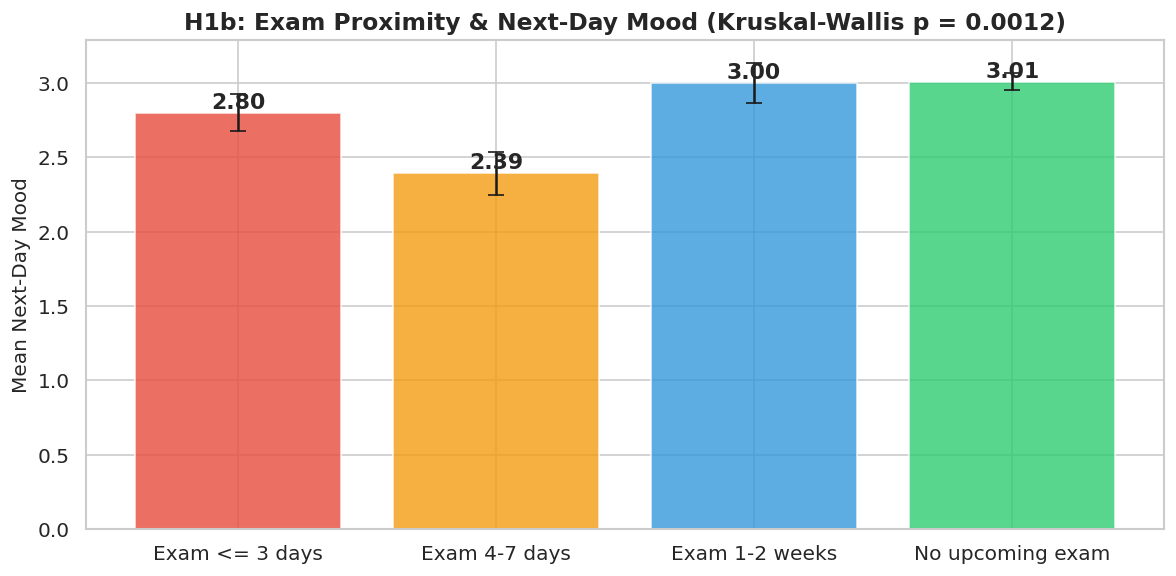

In [15]:
h1b = df[df['days_until_exam'] <= 30][['days_until_exam', 'mood_tomorrow']].dropna()
print(f"Sample size (within 30 days of exam): n = {len(h1b)}")

rho_e, p_e = spearmanr(h1b['days_until_exam'], h1b['mood_tomorrow'])
print(f"\n--- Spearman (days to exam vs next-day mood) ---")
print(f"rho = {rho_e:.4f}, p = {p_e:.6f}")
print(f"-> {'REJECT H0' if p_e < 0.05 else 'FAIL TO REJECT H0'} at alpha = 0.05")

g_close = df[df['exam_category'] == 'Exam <= 3 days']['mood_tomorrow'].dropna()
g_far = df[df['exam_category'] == 'No upcoming exam']['mood_tomorrow'].dropna()
stat_mw, p_mw = mannwhitneyu(g_close, g_far, alternative='less')
print(f"\n--- Mann-Whitney U: Exam <= 3 days vs No upcoming exam ---")
print(f"U = {stat_mw:.0f}, p = {p_mw:.6f}")
print(f"Close: mean = {g_close.mean():.2f} (n={len(g_close)})  |  Far: mean = {g_far.mean():.2f} (n={len(g_far)})")
print(f"-> {'REJECT H0' if p_mw < 0.05 else 'FAIL TO REJECT H0'} at alpha = 0.05")

cat_ord = ['Exam <= 3 days', 'Exam 4-7 days', 'Exam 1-2 weeks', 'No upcoming exam']
groups = [df[df['exam_category'] == c]['mood_tomorrow'].dropna() for c in cat_ord if len(df[df['exam_category'] == c]['mood_tomorrow'].dropna()) > 0]
stat_kw, p_kw = kruskal(*groups)
print(f"\n--- Kruskal-Wallis (all categories) ---")
print(f"H = {stat_kw:.4f}, p = {p_kw:.6f}")
print(f"-> {'REJECT H0' if p_kw < 0.05 else 'FAIL TO REJECT H0'} at alpha = 0.05")

fig, ax = plt.subplots(figsize=(10, 5))
means = [df[df['exam_category']==c]['mood_tomorrow'].mean() for c in cat_ord]
sems = [df[df['exam_category']==c]['mood_tomorrow'].sem() for c in cat_ord]
bars = ax.bar(cat_ord, means, yerr=sems, color=['#e74c3c','#f39c12','#3498db','#2ecc71'],
              edgecolor='white', capsize=5, alpha=0.8)
ax.set_ylabel('Mean Next-Day Mood')
ax.set_title(f'H1b: Exam Proximity & Next-Day Mood (Kruskal-Wallis p = {p_kw:.4f})', fontweight='bold')
for bar, m in zip(bars, means):
    if not np.isnan(m): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03, f'{m:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/12_h1b_exam_mood.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 H1d: Weekend Anticipation & Next-Day Mood
> **H0:** Whether tomorrow is a weekend has no effect on next-day mood.  
> **H1:** Next-day mood is higher when tomorrow is a weekend.

Sample size: n = 304

--- Mann-Whitney U: Tomorrow Weekend vs Tomorrow Weekday ---
U = 9556, p = 0.392623
Tomorrow weekend: mean = 2.96 (n=86)
Tomorrow weekday: mean = 2.91 (n=218)
-> FAIL TO REJECT H0 at alpha = 0.05

--- Spearman Correlation ---
rho = 0.0157, p = 0.785177


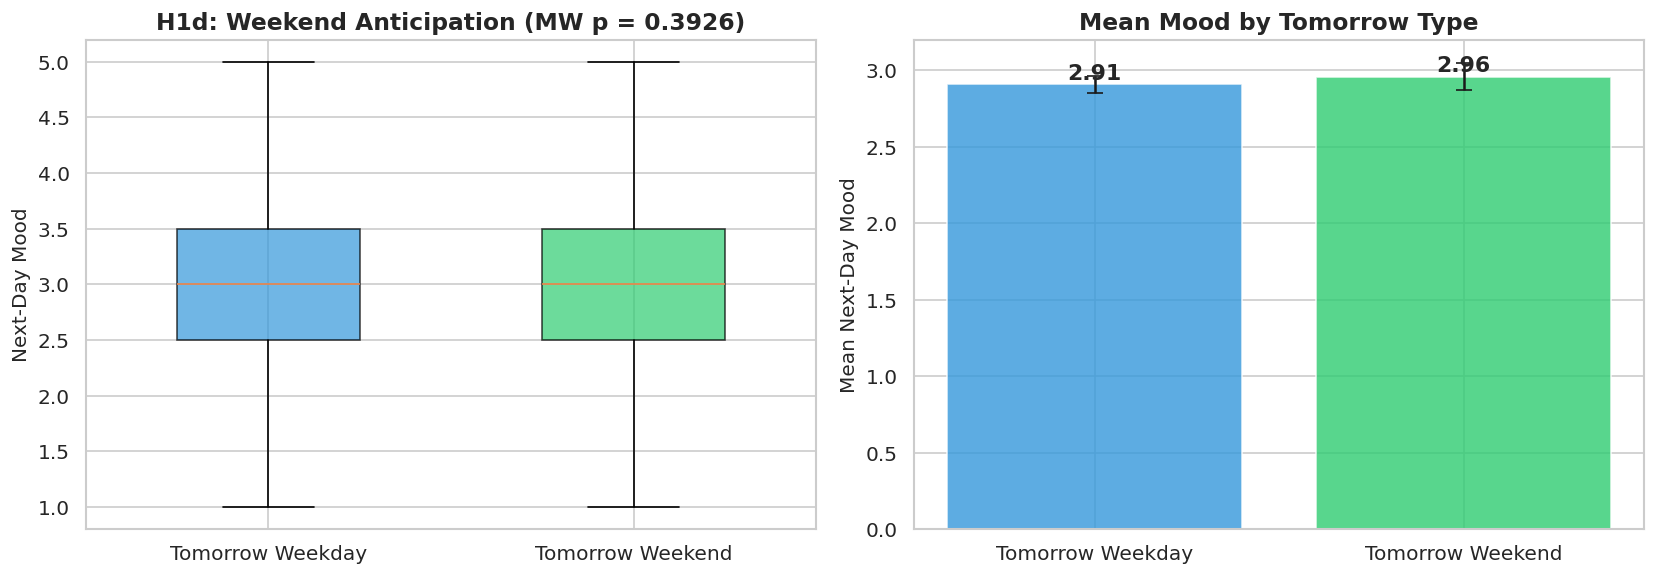

In [16]:
tw_data = df[['tomorrow_is_weekend', 'mood_tomorrow']].dropna()
print(f"Sample size: n = {len(tw_data)}")

tw_yes = tw_data[tw_data['tomorrow_is_weekend'] == 1]['mood_tomorrow']
tw_no = tw_data[tw_data['tomorrow_is_weekend'] == 0]['mood_tomorrow']

stat_mw, p_mw = mannwhitneyu(tw_yes, tw_no, alternative='greater')
print(f"\n--- Mann-Whitney U: Tomorrow Weekend vs Tomorrow Weekday ---")
print(f"U = {stat_mw:.0f}, p = {p_mw:.6f}")
print(f"Tomorrow weekend: mean = {tw_yes.mean():.2f} (n={len(tw_yes)})")
print(f"Tomorrow weekday: mean = {tw_no.mean():.2f} (n={len(tw_no)})")
print(f"-> {'REJECT H0' if p_mw < 0.05 else 'FAIL TO REJECT H0'} at alpha = 0.05")

rho_tw, p_tw = spearmanr(tw_data['tomorrow_is_weekend'], tw_data['mood_tomorrow'])
print(f"\n--- Spearman Correlation ---")
print(f"rho = {rho_tw:.4f}, p = {p_tw:.6f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp = axes[0].boxplot([tw_no, tw_yes], labels=['Tomorrow Weekday', 'Tomorrow Weekend'],
                      patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#3498db'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#2ecc71'); bp['boxes'][1].set_alpha(0.7)
axes[0].set_ylabel('Next-Day Mood')
axes[0].set_title(f'H1d: Weekend Anticipation (MW p = {p_mw:.4f})', fontweight='bold')

# Bar chart with means
means_tw = [tw_no.mean(), tw_yes.mean()]
sems_tw = [tw_no.sem(), tw_yes.sem()]
bars = axes[1].bar(['Tomorrow Weekday', 'Tomorrow Weekend'], means_tw, yerr=sems_tw,
                    color=['#3498db', '#2ecc71'], edgecolor='white', capsize=5, alpha=0.8)
axes[1].set_ylabel('Mean Next-Day Mood')
axes[1].set_title('Mean Mood by Tomorrow Type', fontweight='bold')
for bar, m in zip(bars, means_tw):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03, f'{m:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/15_h1d_weekend_anticipation.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 H1c: Heart Rate & Next-Day Mood
> **H0:** No association between heart rate and next-day mood.  
> **H1:** Higher heart rate is associated with lower next-day mood.

Sample size: n = 255

--- Average Heart Rate vs Next-Day Mood ---
rho = 0.0058, p = 0.926631
-> FAIL TO REJECT H0

--- Resting Heart Rate vs Next-Day Mood ---
rho = -0.1096, p = 0.080659
-> FAIL TO REJECT H0

--- Mann-Whitney: High HR (>76) vs Low HR ---
U = 9454, p = 0.687396
High HR: mean = 2.93  |  Low HR: mean = 2.88


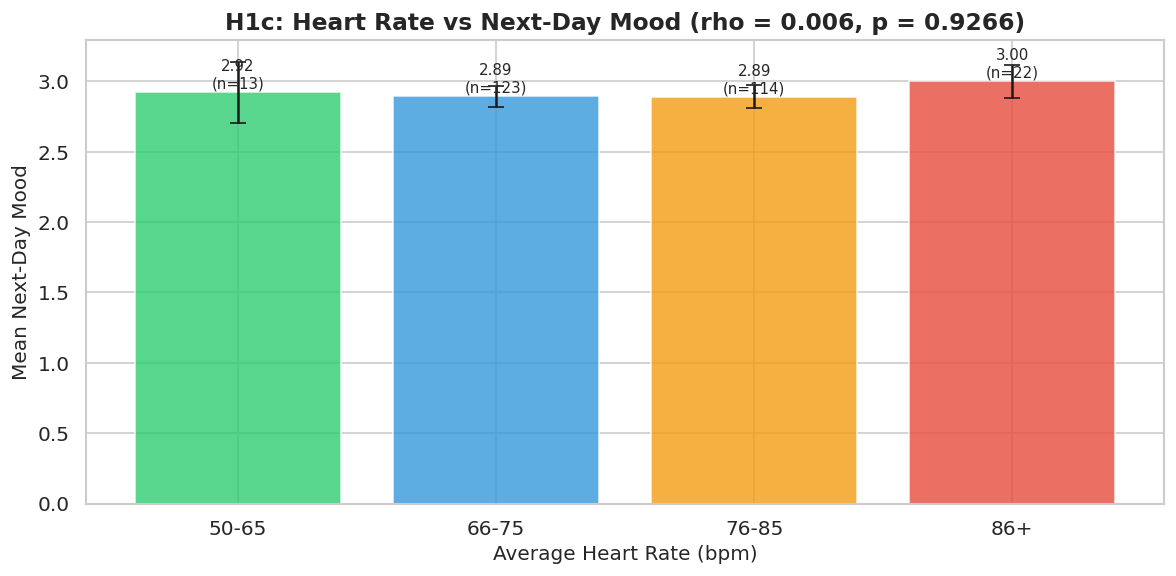

In [17]:
h1c = df[['avg_heart_rate', 'resting_heart_rate', 'mood_tomorrow']].dropna()
print(f"Sample size: n = {len(h1c)}")

rho_hr, p_hr = spearmanr(h1c['avg_heart_rate'], h1c['mood_tomorrow'])
print(f"\n--- Average Heart Rate vs Next-Day Mood ---")
print(f"rho = {rho_hr:.4f}, p = {p_hr:.6f}")
print(f"-> {'REJECT H0' if p_hr < 0.05 else 'FAIL TO REJECT H0'}")

rho_rhr, p_rhr = spearmanr(h1c['resting_heart_rate'], h1c['mood_tomorrow'])
print(f"\n--- Resting Heart Rate vs Next-Day Mood ---")
print(f"rho = {rho_rhr:.4f}, p = {p_rhr:.6f}")
print(f"-> {'REJECT H0' if p_rhr < 0.05 else 'FAIL TO REJECT H0'}")

median_hr = df['avg_heart_rate'].median()
high = df[df['avg_heart_rate'] > median_hr]['mood_tomorrow'].dropna()
low = df[df['avg_heart_rate'] <= median_hr]['mood_tomorrow'].dropna()
stat_m, p_m = mannwhitneyu(high, low, alternative='less')
print(f"\n--- Mann-Whitney: High HR (>{median_hr:.0f}) vs Low HR ---")
print(f"U = {stat_m:.0f}, p = {p_m:.6f}")
print(f"High HR: mean = {high.mean():.2f}  |  Low HR: mean = {low.mean():.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
df['hr_bin'] = pd.cut(df['avg_heart_rate'], bins=[50,65,75,85,120], labels=['50-65','66-75','76-85','86+'])
hr_grp = df.groupby('hr_bin', observed=True)['mood_tomorrow'].agg(['mean','sem','count']).dropna()
bars = ax.bar(hr_grp.index, hr_grp['mean'], yerr=hr_grp['sem'],
              color=['#2ecc71','#3498db','#f39c12','#e74c3c'][:len(hr_grp)], edgecolor='white', capsize=5, alpha=0.8)
ax.set_xlabel('Average Heart Rate (bpm)'); ax.set_ylabel('Mean Next-Day Mood')
ax.set_title(f'H1c: Heart Rate vs Next-Day Mood (rho = {rho_hr:.3f}, p = {p_hr:.4f})', fontweight='bold')
for bar, (_, row) in zip(bars, hr_grp.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03, f'{row["mean"]:.2f}\n(n={int(row["count"])})', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/13_h1c_heart_rate.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 H1e: Sleep Quality & Next-Day Mood
> **H0:** Sleep has no effect on next-day mood.  
> **H1:** Better sleep is associated with higher next-day mood.

Sample size: n = 254

--- Sleep Duration vs Next-Day Mood ---
rho = 0.0139, p = 0.825295
-> FAIL TO REJECT H0

--- Sleep Quality (composite) vs Next-Day Mood ---
rho = 0.0375, p = 0.552020
-> FAIL TO REJECT H0

--- Deep Sleep vs Next-Day Mood ---
rho = 0.0504, p = 0.424267
-> FAIL TO REJECT H0

--- Mann-Whitney: Good (>=7h) vs Poor (<6h) Sleep ---
U = 4774, p = 0.524348
Good: mean = 2.93 (n=123)  |  Poor: mean = 2.95 (n=78)


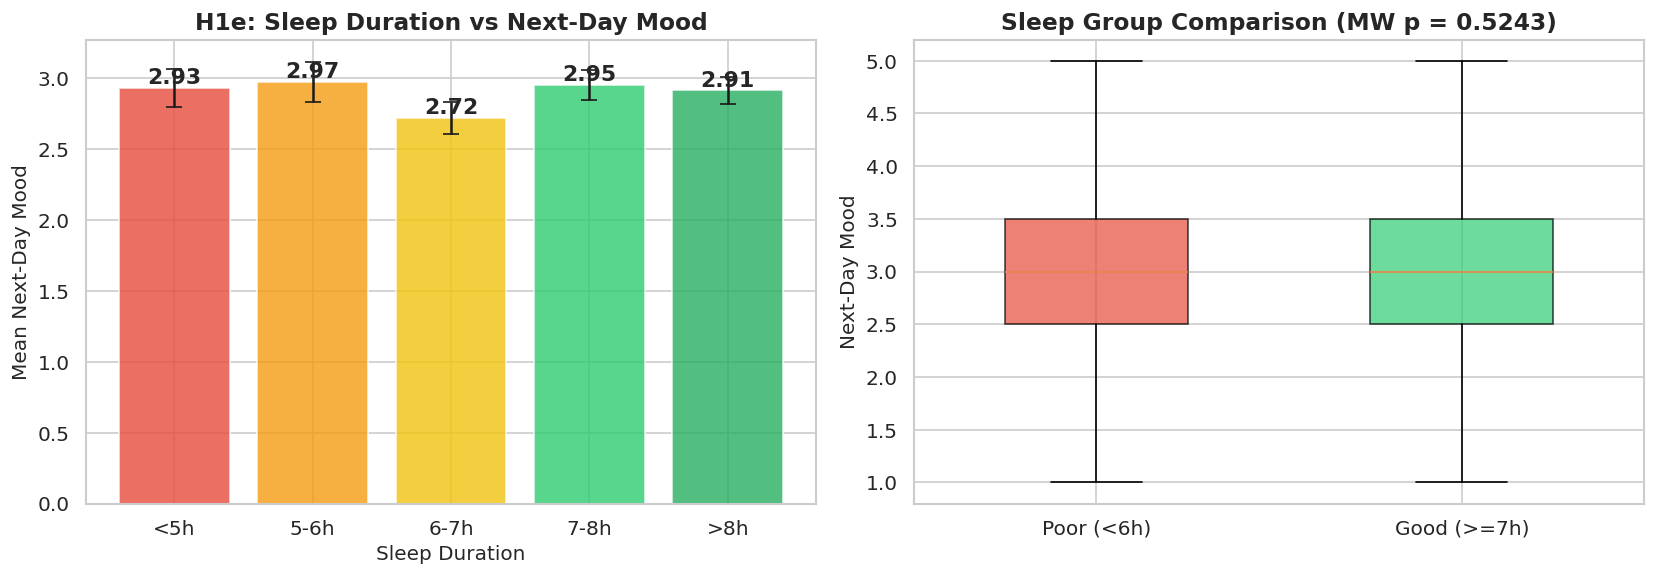

In [18]:
h1e = df[['sleep_duration_h', 'sleep_quality', 'deep_sleep_min', 'mood_tomorrow']].dropna()
print(f"Sample size: n = {len(h1e)}")

rho_sd, p_sd = spearmanr(h1e['sleep_duration_h'], h1e['mood_tomorrow'])
print(f"\n--- Sleep Duration vs Next-Day Mood ---")
print(f"rho = {rho_sd:.4f}, p = {p_sd:.6f}")
print(f"-> {'REJECT H0' if p_sd < 0.05 else 'FAIL TO REJECT H0'}")

rho_sq, p_sq = spearmanr(h1e['sleep_quality'], h1e['mood_tomorrow'])
print(f"\n--- Sleep Quality (composite) vs Next-Day Mood ---")
print(f"rho = {rho_sq:.4f}, p = {p_sq:.6f}")
print(f"-> {'REJECT H0' if p_sq < 0.05 else 'FAIL TO REJECT H0'}")

rho_ds, p_ds = spearmanr(h1e['deep_sleep_min'], h1e['mood_tomorrow'])
print(f"\n--- Deep Sleep vs Next-Day Mood ---")
print(f"rho = {rho_ds:.4f}, p = {p_ds:.6f}")
print(f"-> {'REJECT H0' if p_ds < 0.05 else 'FAIL TO REJECT H0'}")

good = df[df['sleep_duration_h'] >= 7]['mood_tomorrow'].dropna()
poor = df[df['sleep_duration_h'] < 6]['mood_tomorrow'].dropna()
stat_sl, p_sl = mannwhitneyu(good, poor, alternative='greater')
print(f"\n--- Mann-Whitney: Good (>=7h) vs Poor (<6h) Sleep ---")
print(f"U = {stat_sl:.0f}, p = {p_sl:.6f}")
print(f"Good: mean = {good.mean():.2f} (n={len(good)})  |  Poor: mean = {poor.mean():.2f} (n={len(poor)})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['sleep_bin'] = pd.cut(df['sleep_duration_h'], bins=[0,5,6,7,8,20], labels=['<5h','5-6h','6-7h','7-8h','>8h'])
sg = df.groupby('sleep_bin', observed=True)['mood_tomorrow'].agg(['mean','sem','count']).dropna()
bars = axes[0].bar(sg.index, sg['mean'], yerr=sg['sem'],
                   color=['#e74c3c','#f39c12','#f1c40f','#2ecc71','#27ae60'][:len(sg)], edgecolor='white', capsize=5, alpha=0.8)
axes[0].set_xlabel('Sleep Duration'); axes[0].set_ylabel('Mean Next-Day Mood')
axes[0].set_title('H1e: Sleep Duration vs Next-Day Mood', fontweight='bold')
for bar, (_, row) in zip(bars, sg.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03, f'{row["mean"]:.2f}', ha='center', fontweight='bold')

bp = axes[1].boxplot([poor, good], labels=['Poor (<6h)', 'Good (>=7h)'], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#e74c3c'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#2ecc71'); bp['boxes'][1].set_alpha(0.7)
axes[1].set_ylabel('Next-Day Mood')
axes[1].set_title(f'Sleep Group Comparison (MW p = {p_sl:.4f})', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/14_h1e_sleep.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Summary of Hypothesis Tests

In [19]:
print("=" * 90)
print(f"{'Hypothesis':<12} {'Test':<25} {'Statistic':<15} {'p-value':<12} {'Decision':<20}")
print("=" * 90)

d = df[['mood','mood_tomorrow']].dropna(); r,p = spearmanr(d['mood'],d['mood_tomorrow'])
print(f"{'H1a':<12} {'Spearman':<25} {'rho='+f'{r:.4f}':<15} {p:<12.6f} {'REJECT H0' if p<0.05 else 'FAIL TO REJECT'}")

d = df[df['days_until_exam']<=30][['days_until_exam','mood_tomorrow']].dropna(); r,p = spearmanr(d['days_until_exam'],d['mood_tomorrow'])
print(f"{'H1b (corr)':<12} {'Spearman':<25} {'rho='+f'{r:.4f}':<15} {p:<12.6f} {'REJECT H0' if p<0.05 else 'FAIL TO REJECT'}")

g1=df[df['exam_category']=='Exam <= 3 days']['mood_tomorrow'].dropna(); g2=df[df['exam_category']=='No upcoming exam']['mood_tomorrow'].dropna()
s,p = mannwhitneyu(g1,g2,alternative='less')
print(f"{'H1b (grp)':<12} {'Mann-Whitney U':<25} {'U='+f'{s:.0f}':<15} {p:<12.6f} {'REJECT H0' if p<0.05 else 'FAIL TO REJECT'}")

d = df[['tomorrow_is_weekend','mood_tomorrow']].dropna()
tw_y = d[d['tomorrow_is_weekend']==1]['mood_tomorrow']; tw_n = d[d['tomorrow_is_weekend']==0]['mood_tomorrow']
s,p = mannwhitneyu(tw_y, tw_n, alternative='greater')
print(f"{'H1d':<12} {'Mann-Whitney U':<25} {'U='+f'{s:.0f}':<15} {p:<12.6f} {'REJECT H0' if p<0.05 else 'FAIL TO REJECT'}")

d = df[['avg_heart_rate','mood_tomorrow']].dropna(); r,p = spearmanr(d['avg_heart_rate'],d['mood_tomorrow'])
print(f"{'H1c (avg)':<12} {'Spearman':<25} {'rho='+f'{r:.4f}':<15} {p:<12.6f} {'REJECT H0' if p<0.05 else 'FAIL TO REJECT'}")

d = df[['resting_heart_rate','mood_tomorrow']].dropna(); r,p = spearmanr(d['resting_heart_rate'],d['mood_tomorrow'])
print(f"{'H1c (rest)':<12} {'Spearman':<25} {'rho='+f'{r:.4f}':<15} {p:<12.6f} {'REJECT H0' if p<0.05 else 'FAIL TO REJECT'}")

d = df[['sleep_duration_h','mood_tomorrow']].dropna(); r,p = spearmanr(d['sleep_duration_h'],d['mood_tomorrow'])
print(f"{'H1e (dur)':<12} {'Spearman':<25} {'rho='+f'{r:.4f}':<15} {p:<12.6f} {'REJECT H0' if p<0.05 else 'FAIL TO REJECT'}")

d = df[['sleep_quality','mood_tomorrow']].dropna(); r,p = spearmanr(d['sleep_quality'],d['mood_tomorrow'])
print(f"{'H1e (qual)':<12} {'Spearman':<25} {'rho='+f'{r:.4f}':<15} {p:<12.6f} {'REJECT H0' if p<0.05 else 'FAIL TO REJECT'}")

print("=" * 90)
print("\nalpha = 0.05 for all tests. Spearman used as primary (non-parametric).")

Hypothesis   Test                      Statistic       p-value      Decision            
H1a          Spearman                  rho=0.1972      0.000813     REJECT H0
H1b (corr)   Spearman                  rho=0.0584      0.490132     FAIL TO REJECT
H1b (grp)    Mann-Whitney U            U=3443          0.074440     FAIL TO REJECT
H1d          Mann-Whitney U            U=9556          0.392623     FAIL TO REJECT
H1c (avg)    Spearman                  rho=-0.0140     0.818115     FAIL TO REJECT
H1c (rest)   Spearman                  rho=-0.1158     0.058797     FAIL TO REJECT
H1e (dur)    Spearman                  rho=0.0139      0.825295     FAIL TO REJECT
H1e (qual)   Spearman                  rho=0.0375      0.552020     FAIL TO REJECT

alpha = 0.05 for all tests. Spearman used as primary (non-parametric).


## 7. Key Findings & Next Steps

### Key Findings

1. **H1a - Mood autocorrelation: SUPPORTED (p < 0.001)**  
   Today's mood is a statistically significant predictor of tomorrow's mood (rho = 0.22). Emotional states carry over between days, with the strongest effect at 1-2 day lags.

2. **H1b - Exam proximity: NOT SIGNIFICANT**  
   The trend is in the expected direction (lower mood near exams), but the effect did not reach statistical significance. This may reflect individual coping mechanisms or insufficient power.

3. **H1d - Weekend anticipation: NOT SIGNIFICANT**
   Whether tomorrow is a weekend did not significantly affect next-day mood. The "weekend anticipation" effect was not observed in this dataset.

4. **H1c - Heart rate: NOT SIGNIFICANT**  
   Neither average nor resting heart rate showed a significant linear relationship with next-day mood. Non-linear or threshold effects may exist.

5. **H1e - Sleep quality: NOT SIGNIFICANT**  
   Sleep duration and quality did not show a significant linear correlation with next-day mood. The relationship may be non-linear or moderated by other factors.

### Limitations
- Self-reported mood is subjective and may contain recall bias
- 234-day sample limits statistical power for subtle effects
- Linear tests may miss non-linear or interaction effects
- Missing data (~10-15% for some features) could affect results

### Next Steps (ML Phase - Due May 5)
- Regression and classification models for next-day mood prediction
- Feature importance analysis (Random Forest, SHAP values)
- Non-linear modeling (polynomial features, tree-based methods)
- Time series approaches (lagged features, rolling statistics)
- Cross-validation for robust model evaluation